# D2-04 Spatial matching and fallback logic

This notebook focuses on the geography-matching logic used by `edges` once a method file and an inventory are already in place.


## Learning goals

After this notebook, you should be able to:

- explain why spatial matching is needed in regionalised LCIA
- distinguish direct, aggregate, dynamic, contained, and global fallback mapping
- predict which matching strategy should apply in simple geography cases
- identify the helper methods in `edges` that extend matching beyond direct hits


## Background references

- Sacchi, R., Menacho, A. H., Seitfudem, G., Agez, M., Schlesinger-Martinat, J., Koyamparambath, A., Saldivar, J. S., Loubet, P., & Bauer, C. (2025). Contextual LCIA without the overhead: an exchange-based framework for flexible impact assessment. *The International Journal of Life Cycle Assessment, 30*(12), 3087-3101. https://doi.org/10.1007/s11367-025-02551-7


## 1) Why matching logic is needed

A method file may define CFs for `FR`, `RER`, or `GLO`, while the inventory can contain exchanges located in `FR`, `ES`, `CA-QC`, or dynamic locations such as `RoW`. `edges` therefore needs a transparent sequence of matching rules.

In [1]:
import json
from pathlib import Path

import pandas as pd
pd.set_option('display.max_colwidth', None)

example_2_path = Path('assets/edges_examples/lcia_example_2.json')

data = json.loads(example_2_path.read_text())

pd.DataFrame([
    {
        'supplier name': exc['supplier'].get('name'),
        'consumer location': exc['consumer'].get('location'),
        'value': exc['value'],
    }
    for exc in data['exchanges']
])


,supplier name,consumer location,value
0,Carbon dioxide,CH,1.0
1,Carbon dioxide,FR,2.0
2,Carbon dioxide,RER,3.0


## 2) The main matching strategies in `edges`

The four main mapping strategies described in the questionnaire are complemented by a global fallback for the remaining eligible exchanges.  

|   | rule | example | idea |
|---|---|---|---|
| 0 | direct mapping | FR -> FR | The CF exists for the exact same location as the exchange. |
| 1 | aggregate-region<br>mapping | RER | A broader regional factor is computed based on CF of subregions that compose it. |
| 2 | dynamic-location<br>mapping | RoW -> average over<br>remaining country CFs | For dynamic locations such as RoW, `edges` starts from the country CFs available in the method and removes countries already represented explicitly in the inventory. |
| 3 | contained-location<br>mapping | CA-QC -> CA | A subregion inherits the factor of a containing region. |
| 4 | global fallback | XX -> GLO | A global factor is used when no more specific match can be applied. |

## 3) Which `edges` methods implement these steps?

The API mirrors the conceptual workflow quite closely. The diagram below is the usual sequence once `lci()` has built the inventory.  

|   | method | role |
|---|---|---|
| 0 | `map_exchanges()` | Apply the direct matching rules encoded in the method definition. |
| 1 | `map_aggregate_locations()` | Compute CFs for broader static regions such as RER, when exact matches are unavailable. |
| 2 | `map_dynamic_locations()` | Build CF for dynamic regions such as RoW or RoE from the remaining country CFs after explicit locations have been excluded. |
| 3 | `map_contained_locations()` | Use factors for containing regions, such as CA for CA-QC. |
| 4 | `map_remaining_locations_to_global()` | Assign a global fallback to the remaining eligible exchanges. |

## 4) Use `Geomatcher` to inspect aggregate and contained geographies

Before discussing dynamic `RoW`, it helps to isolate the easier cases:

- `ES -> RER` for an aggregate region
- `CA-QC -> CA` for a contained geography

In this section, you query `Geomatcher` directly to explain these static topology relationships.

In [2]:
from contextlib import redirect_stderr, redirect_stdout
import io

from constructive_geometries import Geomatcher

geo = Geomatcher()

def _quiet_geo(method_name, location):
    sink = io.StringIO()
    try:
        with redirect_stdout(sink), redirect_stderr(sink):
            return list(
                getattr(geo, method_name)(
                    location,
                    include_self=False,
                    exclusive=False if method_name == 'within' else True,
                    biggest_first=False,
                )
            )
    except KeyError:
        return None


def _labels(items):
    return [item[1] if isinstance(item, tuple) else str(item) for item in items]


def parents_of(location, limit=12):
    result = _quiet_geo('within', location)
    return [] if result is None else _labels(result)[:limit]


def children_of(location, limit=12):
    result = _quiet_geo('contained', location)
    return [] if result is None else _labels(result)[:limit]


def is_known(location):
    return _quiet_geo('within', location) is not None

Start by looking at both directions of the topology query:

- `within(location)` gives broader regions that contain a location.
- `contained(location)` gives finer subregions contained in a region.

In [4]:
pd.DataFrame([
    {
        'location': location,
        "within(location)": ', '.join(parents_of(location)) or '(none)',
        "contained(location)": ', '.join(children_of(location)) or '(none)',
    }
    for location in ['ES', 'CA-QC', 'BR', 'RER', 'CA']
])

,location,within(location),contained(location)
0,ES,"UN-SEUROPE, UCTE without Germany and France, UCTE without France, UCTE without Germany, IAI Area, EU27 & EFTA, UCTE, RER w/o AT+BE+CH+DE+FR+IT, RER w/o DE+NL+NO+RU, Europe without NORDEL (NCPA), ENTSO-E, RER w/o DE+NL+NO, RER w/o DE+NL+RU",Canary Islands
1,CA-QC,"Québec, HQ distribution network, NPCC, Canada without Alberta, CA, IAI Area, North America, CUSMA/T-MEC/USMCA, NAFTA, RNA, UN-AMERICAS, GLO","Québec, HQ distribution network"
2,BR,"IAI Area, South America, UN-SAMERICA, RLA, UN-AMERICAS, GLO","BR-AC, BR-AL, BR-AM, BR-CE, BR-DF, BR-GO, BR-MG, BR-MS, BR-MT, BR-PB, BR-PI, BR-RO"
3,RER,"UN-EUROPE, GLO","GI, JE, MC, VA, IM, GG, LU, AD, BY, Canary Islands, SK, SM"
4,CA,"IAI Area, North America, CUSMA/T-MEC/USMCA, NAFTA, RNA, UN-AMERICAS, GLO","CA-AB, CA-MB, CA-PE, CA-SK, CA-ON, CA-YK, CA-NB, CA-NS, CA-QC, CA-NT, CA-NF, CA-BC"


The next map stays at the **country** level. It helps visualize the aggregate region `RER` and shows that example inventory locations like `ES` and `IT` sit inside that broader regional CF geography.

Two topology subtleties matter here:

- in `Geomatcher`, Spain is split so that `Canary Islands` is treated separately, so we re-add `ES` explicitly to make mainland Spain visible;
- `Russia (Europe)` is not a sovereign-country polygon, and `country_converter` maps it to `RUS`, which would incorrectly paint all of Russia.

For a country-level map, we therefore re-add `ES` but skip `Canary Islands` and `Russia (Europe)`.

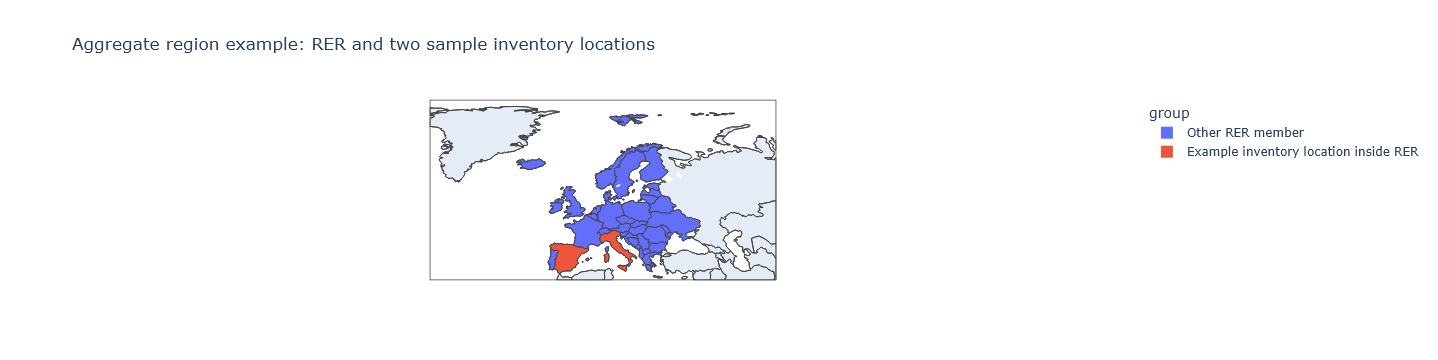

In [5]:
import country_converter as coco
import plotly.express as px

COUNTRY_LEVEL_EXCLUSIONS = {'Canary Islands', 'Russia (Europe)'}


def to_iso3(location):
    sink = io.StringIO()
    with redirect_stdout(sink), redirect_stderr(sink):
        iso3 = coco.convert(names=location, to='ISO3', not_found=None)
    if not iso3 or iso3 == location or len(str(iso3)) != 3:
        return None
    return str(iso3)


def plot_country_groups(groups, title):
    rows = []
    skipped = []
    for location, group in groups.items():
        if location in COUNTRY_LEVEL_EXCLUSIONS:
            skipped.append(f'{location} (cannot be drawn faithfully on a country-level map)')
            continue
        iso3 = to_iso3(location)
        if iso3 is None:
            skipped.append(location)
            continue
        rows.append({'location': location, 'iso3': iso3, 'group': group})
    frame = pd.DataFrame(rows)
    if frame.empty:
        print('No mappable country-level locations found.')
    else:
        fig = px.choropleth(
            frame,
            locations='iso3',
            color='group',
            hover_name='location',
            projection='natural earth',
            title=title,
        )
        fig.update_geos(showcoastlines=True, showcountries=True, fitbounds='locations')
        fig.show()
    if skipped:
        print('Not shown on the country-level map:', skipped)


rer_members = sorted(set(children_of('RER', limit=500)))
rer_members_for_map = sorted((set(rer_members) - COUNTRY_LEVEL_EXCLUSIONS) | {'ES'})
rer_map_groups = {
    location: ('Example inventory location inside RER' if location in {'ES', 'IT'} else 'Other RER member')
    for location in rer_members_for_map
}
plot_country_groups(rer_map_groups, 'Aggregate region example: RER and two sample inventory locations')

In [8]:
geo.add_definitions?

Signature: geo.add_definitions(data: dict, namespace: str, relative: bool = True) -> None
Docstring:
Add new topological definitions to ``self.topology``.

If ``relative`` is true, then ``data`` is defined relative to the existing locations already in ``self.topology``, e.g. IMAGE:

.. code-block:: python

    {"Russia Region": [
        "AM",
        "AZ",
        "GE",
        "RU"
    ]}

Otherwise, ``data`` is a dictionary with string keys and values of integer topology face id sets:

.. code-block:: python

    {
        'A': {1, 2, 3},
        'B': {2, 3, 4},
    }
File:      ~\appdata\local\miniforge3\envs\bw\lib\site-packages\constructive_geometries\geomatcher.py
Type:      method

In [9]:
geo.contained(('ecoinvent', 'RER'))

[('ecoinvent', 'RER'),
 ('ecoinvent', 'Europe without Austria'),
 ('ecoinvent', 'Europe without Switzerland'),
 ('ecoinvent', 'Europe without Switzerland and Austria'),
 ('ecoinvent', 'RER w/o CH+DE'),
 ('ecoinvent', 'Europe, without Russia and Türkiye'),
 ('ecoinvent', 'RER w/o RU'),
 ('ecoinvent', 'Europe without Switzerland and France'),
 ('ecoinvent', 'RER w/o DE+NL+RU'),
 ('ecoinvent', 'RER w/o DE+NL+NO'),
 ('ecoinvent', 'ENTSO-E'),
 ('ecoinvent', 'Europe without NORDEL (NCPA)'),
 ('ecoinvent', 'RER w/o DE+NL+NO+RU'),
 ('ecoinvent', 'RER w/o AT+BE+CH+DE+FR+IT'),
 ('ecoinvent', 'UCTE'),
 ('ecoinvent', 'IAI Area, EU27 & EFTA'),
 ('ecoinvent', 'UCTE without Germany'),
 ('ecoinvent', 'UCTE without France'),
 ('ecoinvent', 'UCTE without Germany and France'),
 ('ecoinvent', 'UN-SEUROPE'),
 ('ecoinvent', 'UN-NEUROPE'),
 'GB',
 ('ecoinvent', 'WEU'),
 ('ecoinvent', 'NORDEL'),
 'SI',
 ('ecoinvent', 'BALTSO'),
 'IT',
 ('ecoinvent', 'Russia (Europe)'),
 'LV',
 'NO',
 'FR',
 'GR',
 'MK',
 ('ec

## Checkpoint 2

Use `constructive_geometries.Geomatcher` to fill in the missing answers.  

|   | location | question | your answer |
|---|---|---|---|
| 0 | ES | One broader region returned by `within(ES)` |  |
| 1 | CA-QC | Containing country used to explain CA-QC |  |
| 2 | BR | Is BR inside RER? (True/False) |  |
| 3 | XX | Is XX known to Geomatcher? (True/False) |  |

In [10]:
from constructive_geometries import Geomatcher
# from edges.georesolver import Geomatcher this works too since `edges` exposes Geomatcher

In [11]:
geo = Geomatcher()

In [12]:
geo.within("ES")

['GLO',
 ('ecoinvent', 'UN-EUROPE'),
 ('ecoinvent', 'RER'),
 ('ecoinvent', 'Europe without Austria'),
 ('ecoinvent', 'Europe without Switzerland'),
 ('ecoinvent', 'Europe without Switzerland and Austria'),
 ('ecoinvent', 'RER w/o CH+DE'),
 ('ecoinvent', 'Europe, without Russia and Türkiye'),
 ('ecoinvent', 'RER w/o RU'),
 ('ecoinvent', 'Europe without Switzerland and France'),
 ('ecoinvent', 'RER w/o DE+NL+RU'),
 ('ecoinvent', 'RER w/o DE+NL+NO'),
 ('ecoinvent', 'ENTSO-E'),
 ('ecoinvent', 'Europe without NORDEL (NCPA)'),
 ('ecoinvent', 'RER w/o DE+NL+NO+RU'),
 ('ecoinvent', 'RER w/o AT+BE+CH+DE+FR+IT'),
 ('ecoinvent', 'UCTE'),
 ('ecoinvent', 'IAI Area, EU27 & EFTA'),
 ('ecoinvent', 'UCTE without Germany'),
 ('ecoinvent', 'UCTE without France'),
 ('ecoinvent', 'UCTE without Germany and France'),
 ('ecoinvent', 'UN-SEUROPE'),
 'ES']

In [13]:
geo.within("CA-QC")

['GLO',
 ('ecoinvent', 'UN-AMERICAS'),
 ('ecoinvent', 'RNA'),
 ('ecoinvent', 'CUSMA/T-MEC/USMCA'),
 ('ecoinvent', 'NAFTA'),
 ('ecoinvent', 'IAI Area, North America'),
 'CA',
 ('ecoinvent', 'Canada without Alberta'),
 ('ecoinvent', 'NPCC'),
 ('ecoinvent', 'CA-QC'),
 ('ecoinvent', 'Québec, HQ distribution network')]

In [14]:
"BR" in geo.contained(("ecoinvent", "RER"))

False

In [15]:
geo.contained(("ecoinvent", "RER"))

[('ecoinvent', 'RER'),
 ('ecoinvent', 'Europe without Austria'),
 ('ecoinvent', 'Europe without Switzerland'),
 ('ecoinvent', 'Europe without Switzerland and Austria'),
 ('ecoinvent', 'RER w/o CH+DE'),
 ('ecoinvent', 'Europe, without Russia and Türkiye'),
 ('ecoinvent', 'RER w/o RU'),
 ('ecoinvent', 'Europe without Switzerland and France'),
 ('ecoinvent', 'RER w/o DE+NL+RU'),
 ('ecoinvent', 'RER w/o DE+NL+NO'),
 ('ecoinvent', 'ENTSO-E'),
 ('ecoinvent', 'Europe without NORDEL (NCPA)'),
 ('ecoinvent', 'RER w/o DE+NL+NO+RU'),
 ('ecoinvent', 'RER w/o AT+BE+CH+DE+FR+IT'),
 ('ecoinvent', 'UCTE'),
 ('ecoinvent', 'IAI Area, EU27 & EFTA'),
 ('ecoinvent', 'UCTE without Germany'),
 ('ecoinvent', 'UCTE without France'),
 ('ecoinvent', 'UCTE without Germany and France'),
 ('ecoinvent', 'UN-SEUROPE'),
 ('ecoinvent', 'UN-NEUROPE'),
 'GB',
 ('ecoinvent', 'WEU'),
 ('ecoinvent', 'NORDEL'),
 'SI',
 ('ecoinvent', 'BALTSO'),
 'IT',
 ('ecoinvent', 'Russia (Europe)'),
 'LV',
 'NO',
 'FR',
 'GR',
 'MK',
 ('ec

In [16]:
"XX" in geo.keys()

False

In [ ]:
# we can list all entitites known by `Geomatcher`
list(geo.keys())

## 5) Dynamic `RoW` on a real BAFU activity

`RoW` is different from `RER` or `CA`. It is not a fixed region in the method file. Instead, `edges` builds it dynamically from the **country CFs** that remain available after excluding same-product locations already present in the inventory.

Here we use `Natural gas, burned in gas turbine` at location `RoW` for two complementary views:

- the **actual** `edges` behavior with a country-level teaching method;
- a **counterfactual teaching view** where we ignore aggregate inventory locations and ask a simpler question: which countries would remain in `RoW` if we excluded only the explicit same-product country datasets?

This teaching simplification matches the structure of `edges` method files, which only contain country CFs here.


In [17]:
import json
import tempfile
from pathlib import Path

import bw2data as bd
import numpy as np
from IPython.display import display
from edges import EdgeLCIA

Start by locating the activity and listing the same-product locations already present in the inventory.

In [18]:
bd.projects.set_current('aalborg-rlcia-2026')
db_name = 'bafu'

db = bd.Database(db_name)

bafu_activity = [
        act for act in db
        if act['name'].startswith("Natural gas, burned in gas turbine")
        and act.get('location') == 'RoW'
][0]
bafu_activity

'Natural gas, burned in gas turbine' (megajoule, RoW, None)

In [19]:
bafu_activity.as_dict()

{'code': 'bafu-415895',
 'comment': 'The net calorific value of natural gas is 36.0 MJ/Nm³. UUID=8a92b2f4-8569-3be6-95e5-08ec7cd143a6\nTime period: Data steem from the mid 1990s.\nGeography: RoW – CO2-emissions based on average Swiss gas composition.\nRepresentativeness: Sampling: Literature.; Extrapolations: none\nData entry: Maresa Bussa (anonymised)\nData generator: Niels Jungbluth (anonymised)\nProof-reading validator: Niels Jungbluth (anonymised)\nValidation details: Passed.\nSource: Meili C. Jungbluth N., Bussa M., Stefanel A. (2025) 2025 - LCI long-distance transport crude oil - Meili ESU-services Ltd., Schaffhausen, CH, vol. 234',
 'filename': 'process_8a92b2f4-8569-3be6-95e5-08ec7cd143a6.xml',
 'location': 'RoW',
 'reference product': 'Natural gas, burned in gas turbine',
 'type': 'processwithreferenceproduct',
 'unit': 'megajoule',
 'name': 'Natural gas, burned in gas turbine',
 'worksheet name': 'bafu',
 'database': 'bafu',
 'id': 358589350268850184}

In [20]:
for e in bafu_activity.exchanges():
    print(e["name"], " | ", e.get("product"), " | ", e["amount"], " | ", e["unit"], " | ",  e["type"])

Carbon dioxide, fossil  |  None  |  0.056  |  kilogram  |  biosphere
Carbon monoxide, fossil  |  None  |  4e-05  |  kilogram  |  biosphere
Dinitrogen monoxide  |  None  |  1e-06  |  kilogram  |  biosphere
Dioxins, measured as 2,3,7,8-tetrachlorodibenzo-p-dioxin  |  None  |  2.9e-17  |  kilogram  |  biosphere
Heat, waste  |  None  |  1.1  |  megajoule  |  biosphere
Mercury II  |  None  |  3e-11  |  kilogram  |  biosphere
Methane, fossil  |  None  |  4.5e-06  |  kilogram  |  biosphere
NMVOC, non-methane volatile organic compounds  |  None  |  1e-06  |  kilogram  |  biosphere
Nitrogen oxides  |  None  |  0.00013  |  kilogram  |  biosphere
Sulfur dioxide  |  None  |  5.5e-07  |  kilogram  |  biosphere
Natural gas, burned in gas turbine  |  None  |  1  |  megajoule  |  production
Gas turbine, 10MWe, at production plant  |  None  |  1.15e-10  |  unit  |  technosphere
Natural gas, high pressure, at consumer  |  None  |  1  |  megajoule  |  technosphere


Let's build a fake method that contains a CF for all the countries in the world.


Two different interpretations are now useful:

1. **Actual `edges` behavior**: because `GLO` is one of the same-product locations in the inventory, the dynamic `RoW` pool can collapse.
2. **Counterfactual teaching view**: if we ignore `GLO` just for the map, we can still visualize the distinction between countries with explicit datasets and countries that would otherwise remain in `RoW`.

The next cells show both on purpose.

In [21]:
import country_converter as coco
world_country_codes = [
    code
    for code in sorted(coco.CountryConverter().data['ISO2'].dropna().astype(str).unique()) if len(code) == 2 
]
world_country_codes

['AD',
 'AE',
 'AF',
 'AG',
 'AI',
 'AL',
 'AM',
 'AO',
 'AQ',
 'AR',
 'AS',
 'AT',
 'AU',
 'AW',
 'AX',
 'AZ',
 'BA',
 'BB',
 'BD',
 'BE',
 'BF',
 'BG',
 'BH',
 'BI',
 'BJ',
 'BL',
 'BM',
 'BN',
 'BO',
 'BQ',
 'BR',
 'BS',
 'BT',
 'BV',
 'BW',
 'BY',
 'BZ',
 'CA',
 'CC',
 'CD',
 'CF',
 'CG',
 'CH',
 'CI',
 'CK',
 'CL',
 'CM',
 'CN',
 'CO',
 'CR',
 'CU',
 'CV',
 'CW',
 'CX',
 'CY',
 'CZ',
 'DE',
 'DJ',
 'DK',
 'DM',
 'DO',
 'DZ',
 'EC',
 'EE',
 'EG',
 'EH',
 'ER',
 'ES',
 'ET',
 'FI',
 'FJ',
 'FK',
 'FM',
 'FO',
 'FR',
 'GA',
 'GD',
 'GE',
 'GF',
 'GG',
 'GH',
 'GI',
 'GL',
 'GM',
 'GN',
 'GP',
 'GQ',
 'GS',
 'GT',
 'GU',
 'GW',
 'GY',
 'HK',
 'HM',
 'HN',
 'HR',
 'HT',
 'HU',
 'ID',
 'IE',
 'IL',
 'IM',
 'IN',
 'IO',
 'IQ',
 'IR',
 'IS',
 'IT',
 'JE',
 'JM',
 'JO',
 'JP',
 'KE',
 'KG',
 'KH',
 'KI',
 'KM',
 'KN',
 'KP',
 'KR',
 'KW',
 'KY',
 'KZ',
 'LA',
 'LB',
 'LC',
 'LI',
 'LK',
 'LR',
 'LS',
 'LT',
 'LU',
 'LV',
 'LY',
 'MA',
 'MC',
 'MD',
 'ME',
 'MF',
 'MG',
 'MH',
 'MK',
 'ML',

In [22]:
rng = np.random.default_rng(2026)

country_factors = {code: {
        "value": int(rng.integers(1, 100)),
        "weight": int(rng.integers(1, 100)),
    }
    for code in world_country_codes
}


dynamic_method = {
    'name': 'Dynamic RoW teaching example',
    'version': '1.0',
    'unit': 'kg CO2-eq',
    'description': 'Teaching method with one country CF for every country.',
    'exchanges': [
        {
            'supplier': {'name': 'Carbon dioxide, fossil', 'matrix': 'biosphere'},
            'consumer': {'matrix': 'technosphere', 'location': loc},
            'value': dictionary["value"],
            'weight': dictionary["weight"],
        }
        for loc, dictionary in country_factors.items()
    ],
}
dynamic_method


{'name': 'Dynamic RoW teaching example',
 'version': '1.0',
 'unit': 'kg CO2-eq',
 'description': 'Teaching method with one country CF for every country.',
 'exchanges': [{'supplier': {'name': 'Carbon dioxide, fossil',
    'matrix': 'biosphere'},
   'consumer': {'matrix': 'technosphere', 'location': 'AD'},
   'value': 85,
   'weight': 18},
  {'supplier': {'name': 'Carbon dioxide, fossil', 'matrix': 'biosphere'},
   'consumer': {'matrix': 'technosphere', 'location': 'AE'},
   'value': 3,
   'weight': 64},
  {'supplier': {'name': 'Carbon dioxide, fossil', 'matrix': 'biosphere'},
   'consumer': {'matrix': 'technosphere', 'location': 'AF'},
   'value': 37,
   'weight': 47},
  {'supplier': {'name': 'Carbon dioxide, fossil', 'matrix': 'biosphere'},
   'consumer': {'matrix': 'technosphere', 'location': 'AG'},
   'value': 8,
   'weight': 37},
  {'supplier': {'name': 'Carbon dioxide, fossil', 'matrix': 'biosphere'},
   'consumer': {'matrix': 'technosphere', 'location': 'AI'},
   'value': 64,
  

Now let's run `edges` with that method and see if `RoW` exchanges get a CF

In [23]:
row_lca = EdgeLCIA(
    demand={bafu_activity: 1},
    method=dynamic_method,
)
row_lca.lci()
row_lca.map_exchanges()
row_lca.map_aggregate_locations()
row_lca.map_dynamic_locations()
row_lca.evaluate_cfs()
row_lca.lcia()

In [24]:
cf_table = row_lca.generate_cf_table()

gas_turbine_carbon_row = cf_table[
    (cf_table["supplier name"] == "Carbon dioxide, fossil")
    & (cf_table["consumer name"] == bafu_activity["name"])
    & (cf_table["consumer reference product"] == bafu_activity["reference product"])
    & (cf_table["consumer location"] == "RoW")
].iloc[0]

In [25]:
gas_turbine_carbon_row[[
    "supplier name",
    "consumer name",
    "consumer location",
    "CF",
    "impact",
]].to_frame().T

,supplier name,consumer name,consumer location,CF,impact
1425,"Carbon dioxide, fossil","Natural gas, burned in gas turbine",RoW,47.588442,2.678095


In [26]:
same_product_family_locations = sorted({
    act["location"]
    for act in db
    if act["name"] == bafu_activity["name"]
    and act["reference product"] == bafu_activity["reference product"]
})
explicit_country_locations = [
    loc for loc in same_product_family_locations 
    if loc in world_country_codes
]
aggregate_locations = [
    loc for loc in same_product_family_locations 
    if loc not in explicit_country_locations
]
dynamic_row_pool_counterfactual = [
    country for country in world_country_codes 
    if country not in explicit_country_locations
]

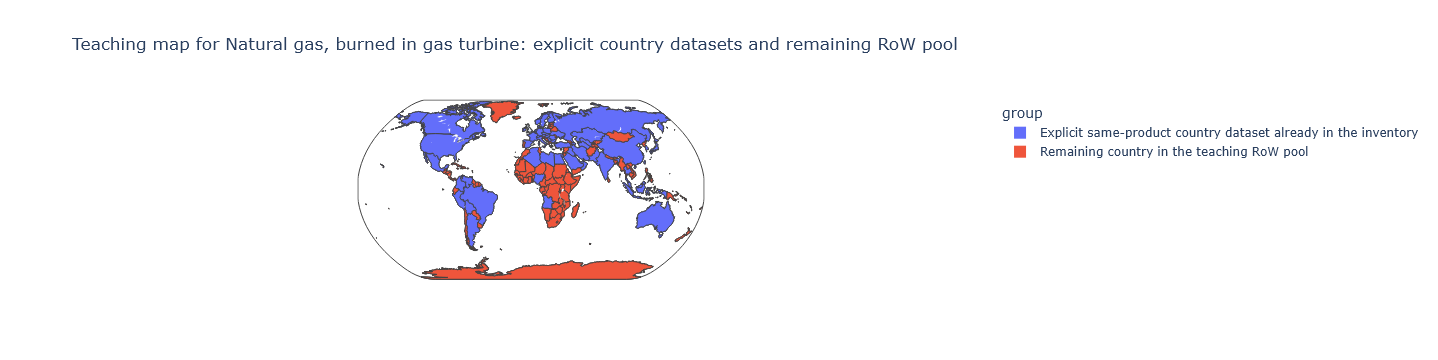

In [27]:
row_map_groups = {
    **{loc: 'Explicit same-product country dataset already in the inventory' for loc in explicit_country_locations},
    **{loc: 'Remaining country in the teaching RoW pool' for loc in dynamic_row_pool_counterfactual},
}
plot_country_groups(
    row_map_groups,
    'Teaching map for Natural gas, burned in gas turbine: explicit country datasets and remaining RoW pool'
)

We can also manually reproduce the `RoW` CF for this exact gas-turbine dataset. The map above is a **counterfactual teaching view**: it excludes explicit same-product country datasets, but it intentionally ignores aggregate same-product datasets such as `RER` and `Europe without Switzerland`.

The actual `edges` result is stricter. It excludes explicit same-product locations **and** the countries contained in same-product aggregate regions. To reproduce the exact CF, use the `reporting_split` components that `edges` stores on the matched entry in `cfs_mapping`; these components are the actual countries, shares, and CF values used in the weighted average.


In [28]:
def find_characterized_exchange_mapping(lca, supplier_name, consumer_activity):
    for entry in lca.cfs_mapping:
        if entry.get("supplier", {}).get("name") != supplier_name:
            continue

        for _, consumer_idx in entry.get("positions", ()):
            consumer_info = lca.position_to_technosphere_flows_lookup.get(consumer_idx, {})
            if (
                consumer_info.get("name") == consumer_activity["name"]
                and consumer_info.get("reference product") == consumer_activity["reference product"]
                and consumer_info.get("location") == consumer_activity["location"]
            ):
                return entry

    raise LookupError("No matching characterized exchange was found.")


gas_turbine_carbon_mapping = find_characterized_exchange_mapping(
    row_lca,
    supplier_name="Carbon dioxide, fossil",
    consumer_activity=bafu_activity,
)

actual_row_components = list(gas_turbine_carbon_mapping.get("reporting_split", ()))

actual_row_pool = sorted({
    component["consumer_location"]
    for component in actual_row_components
})

In [29]:
print(f"countries in actual edges RoW pool: {len(actual_row_pool)}")

countries in actual edges RoW pool: 161


In [30]:
print(f"countries in manual RoW pool: {len(dynamic_row_pool_counterfactual)}")

countries in manual RoW pool: 187


In [31]:
counterfactual_json_cfs = [
    exc
    for exc in dynamic_method["exchanges"]
    if exc["supplier"]["name"] == "Carbon dioxide, fossil"
    and exc["consumer"]["location"] in dynamic_row_pool_counterfactual
]
counterfactual_weights = np.array([exc["weight"] for exc in counterfactual_json_cfs], dtype=float)
counterfactual_shares = counterfactual_weights / counterfactual_weights.sum()
counterfactual_row_cf = float(sum(
    share * exc["value"]
    for share, exc in zip(counterfactual_shares, counterfactual_json_cfs)
))
print(f"Manual RoW CF from map-only pool: {counterfactual_row_cf}")

Manual RoW CF from map-only pool: 47.99294068064483


In [32]:
print(f"RoW CF calculated by edges: {float(gas_turbine_carbon_row['CF'])}")

RoW CF calculated by edges: 47.58844221105529


## Recap

After this notebook, you should now be able to:

- explain why spatial matching is needed in `edges`
- connect each conceptual matching rule to the corresponding helper method in the API
- query `Geomatcher` directly to explain aggregate and contained geographies
- explain why dynamic `RoW` is computed from the remaining country CFs instead of read as a fixed factor
- distinguish a real run where `RoW` collapses because `GLO` is present from a counterfactual map that ignores `GLO` for teaching purposes
- use simple maps to explain aggregate regions and dynamic-country pools